In [1]:
from utils import DQN, ReplayBuffer, greedy_action, epsilon_greedy, update_target, loss

import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import math
import numpy as np

import gymnasium as gym
import matplotlib.pyplot as plt

## Q1.1 Hyperparameters 

In [3]:
# hyperparameters

NUM_RUNS = 10
NUM_EPISODES = 300


# network
LAYER_SIZES = [4, 64, 64, 2]   # 2 hidden layers

# optimizer
LEARNING_RATE = 4e-3

# replay buffer
BUFFER_SIZE = 50000
BATCH_SIZE = 128
MIN_BUFFER = 1000   # start training after some data
TRAIN_FREQ = 4      # don't train every step

# discount
GAMMA = 0.99

# epsilon (exploration)
EPS_START = 1.0
EPS_END = 0.01
#EPS_DECAY = 50  
EPS_DECAY = 75   

# soft update
TAU = 0.01



## Q1.2 Exploration

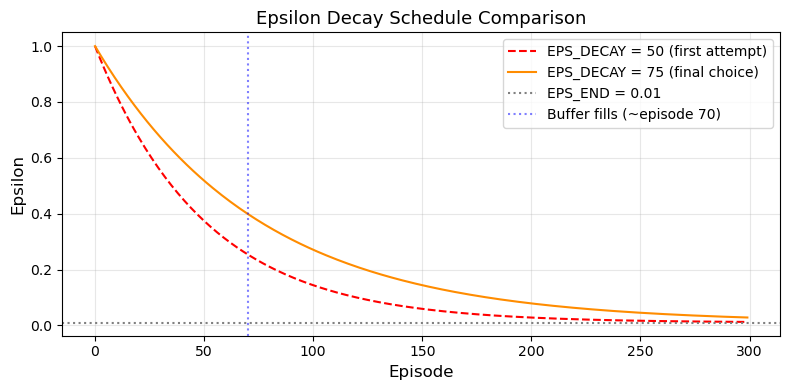

In [5]:
# Q1.2 — Epsilon decay schedule plot
eps_50 = [EPS_END + (EPS_START - EPS_END) * math.exp(-ep / 50) for ep in range(NUM_EPISODES)]
eps_75 = [EPS_END + (EPS_START - EPS_END) * math.exp(-ep / EPS_DECAY) for ep in range(NUM_EPISODES)]

plt.figure(figsize=(8, 4))
plt.plot(eps_50, color='red', linestyle='--', label='EPS_DECAY = 50 (first attempt)')
plt.plot(eps_75, color='darkorange', label='EPS_DECAY = 75 (final choice)')
plt.axhline(y=EPS_END, color='gray', linestyle=':', label=f'EPS_END = {EPS_END}')
plt.axvline(x=70, color='blue', linestyle=':', alpha=0.5, label='Buffer fills (~episode 70)')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Epsilon', fontsize=12)
plt.title('Epsilon Decay Schedule Comparison', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('epsilon_decay.png', dpi=150)
plt.show()

## Q1.3 Training: 10 runs

In [29]:
runs_results = []

env = gym.make('CartPole-v1')

for run in range(NUM_RUNS):
    print(f"\nStarting run {run+1} of {NUM_RUNS}")

    policy_net = DQN(LAYER_SIZES)
    target_net = DQN(LAYER_SIZES)
    update_target(target_net, policy_net)
    target_net.eval()

    #optim.SGD(policy_net.parameters(), lr=1.)
    optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
    #ReplayBuffer(1) — buffer of size 1
    memory = ReplayBuffer(BUFFER_SIZE)

    episode_durations = []
    total_steps = 0

    #for i_episode in range(300):
    for i_episode in range(NUM_EPISODES):
        if (i_episode + 1) % 50 == 0:
            print(f"  episode {i_episode+1}/{NUM_EPISODES}  |  last return: {episode_durations[-1]}")
            

         # epsilon decay
        epsilon = EPS_END + (EPS_START - EPS_END) * math.exp(-i_episode / EPS_DECAY)

        observation, info = env.reset()
        state = torch.tensor(observation).float()

        truncated  = False
        terminated = False
        t = 0

        while not (truncated or terminated):

            # choose action
            action = epsilon_greedy(epsilon, policy_net, state)

            observation, reward, terminated, truncated, info = env.step(action)
            reward     = torch.tensor([reward])
            action     = torch.tensor([action])
            next_state = torch.tensor(observation).reshape(-1).float()


            memory.push([state, action, next_state, reward, torch.tensor([terminated])])

            state = next_state
            total_steps += 1

            if len(memory.buffer) >= MIN_BUFFER and total_steps % TRAIN_FREQ == 0:
                transitions = memory.sample(BATCH_SIZE)
                state_batch, action_batch, nextstate_batch, reward_batch, dones = (
                    torch.stack(x) for x in zip(*transitions)
                )
                mse_loss = loss(
                    policy_net, target_net,
                    state_batch, action_batch,
                    reward_batch, nextstate_batch,
                    dones, gamma=GAMMA
                )
                optimizer.zero_grad()
                mse_loss.backward()
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10.0)
                optimizer.step()

                
                # target = TAU * policy + (1 - TAU) * target
                for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
                    target_param.data.copy_(TAU * policy_param.data + (1 - TAU) * target_param.data)

            if truncated or terminated:
                episode_durations.append(t + 1)
            t += 1

    runs_results.append(episode_durations)

trained_policy_net = policy_net

print("All runs complete!")



Starting run 1 of 10
  episode 50/300  |  last return: 14
  episode 100/300  |  last return: 9
  episode 150/300  |  last return: 10
  episode 200/300  |  last return: 164
  episode 250/300  |  last return: 119
  episode 300/300  |  last return: 136

Starting run 2 of 10
  episode 50/300  |  last return: 10
  episode 100/300  |  last return: 9
  episode 150/300  |  last return: 12
  episode 200/300  |  last return: 213
  episode 250/300  |  last return: 145
  episode 300/300  |  last return: 164

Starting run 3 of 10
  episode 50/300  |  last return: 13
  episode 100/300  |  last return: 10
  episode 150/300  |  last return: 191
  episode 200/300  |  last return: 192
  episode 250/300  |  last return: 158
  episode 300/300  |  last return: 232

Starting run 4 of 10
  episode 50/300  |  last return: 19
  episode 100/300  |  last return: 13
  episode 150/300  |  last return: 172
  episode 200/300  |  last return: 165
  episode 250/300  |  last return: 128
  episode 300/300  |  last retu

## Q1.3 Learning curve plot (mean ± std over 10 runs)

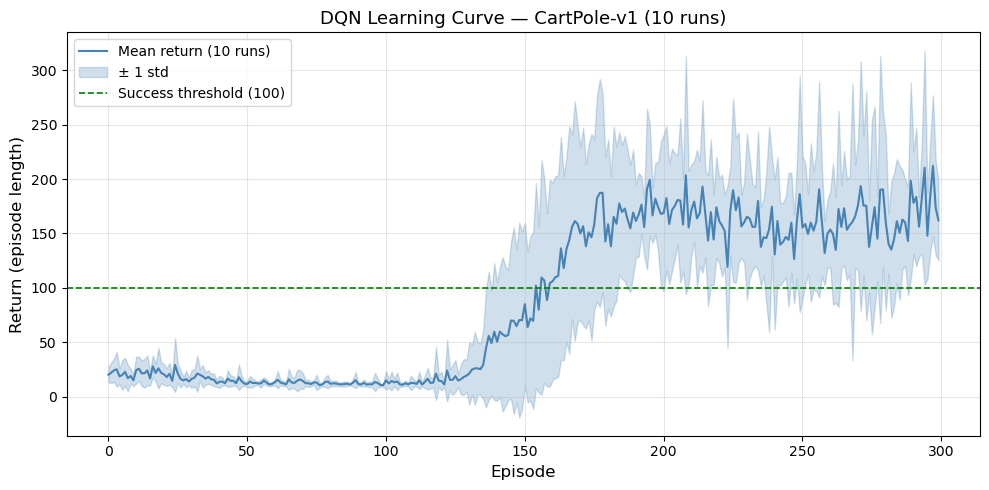

In [31]:
results = torch.tensor(runs_results, dtype=torch.float)
means   = results.mean(0)
stds    = results.std(0)
episodes = np.arange(NUM_EPISODES)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(episodes, means, color='steelblue', label='Mean return (10 runs)')
ax.fill_between(episodes, means - stds, means + stds,
                alpha=0.25, color='steelblue', label='± 1 std')

ax.axhline(y=100, color='green', linestyle='--', linewidth=1.2, label='Success threshold (100)')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Return (episode length)', fontsize=12)
ax.set_title('DQN Learning Curve — CartPole-v1 (10 runs)', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()

## Q2.1 Greedy policy slices (4 cart velocities)

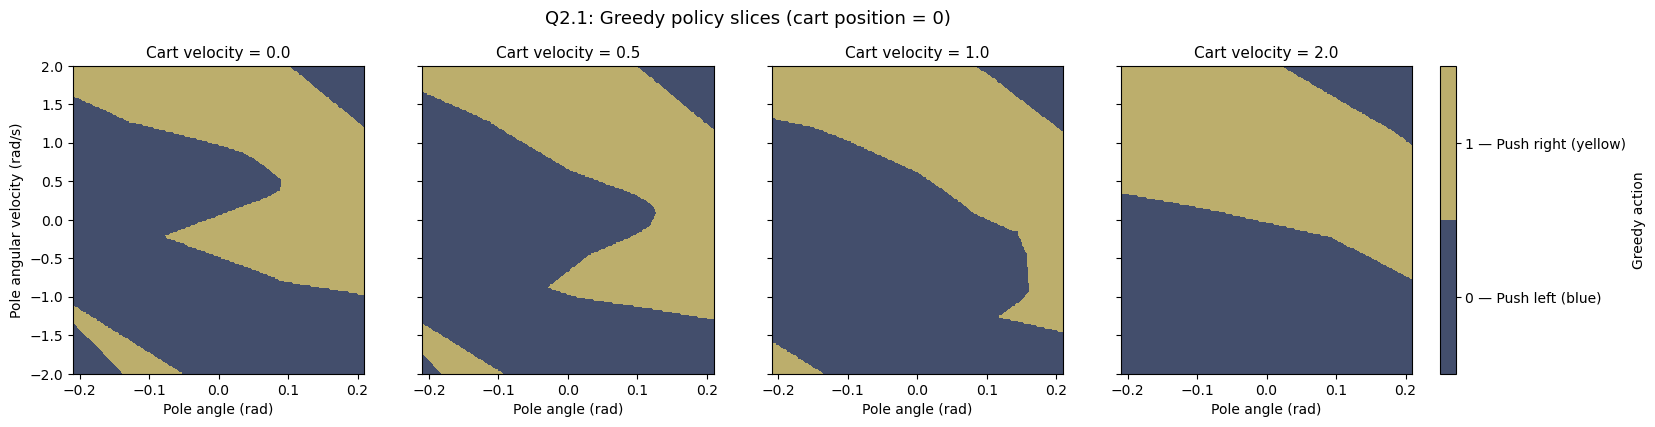

In [57]:
cart_velocities = [0.0, 0.5, 1.0, 2.0]

angle_range  = 0.2095 
omega_range  = 2.0      
n_samples    = 200

angles = torch.linspace(-angle_range, angle_range, n_samples)
omegas = torch.linspace(-omega_range, omega_range, n_samples)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for ax, cart_vel in zip(axes, cart_velocities):
    policy_array = torch.zeros((n_samples, n_samples))

    for i, angle in enumerate(angles):
        for j, omega in enumerate(omegas):
            state = torch.tensor([0., cart_vel, angle, omega])
            with torch.no_grad():
                action = trained_policy_net(state).argmax().item()
            policy_array[i, j] = action

    img = ax.contourf(angles.numpy(), omegas.numpy(), policy_array.T.numpy(),
                      levels=[-0.5, 0.5, 1.5], cmap='cividis')
    ax.set_title(f'Cart velocity = {cart_vel}', fontsize=11)
    ax.set_xlabel('Pole angle (rad)', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('Pole angular velocity (rad/s)', fontsize=10)

# Shared colourbar
cbar = fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0 — Push left (blue)', '1 — Push right (yellow)'])
cbar.set_label('Greedy action', fontsize=10)

fig.suptitle('Q2.1: Greedy policy slices (cart position = 0)', fontsize=13, y=1.02)
#plt.tight_layout()
plt.savefig('policy_slices.png', dpi=150, bbox_inches='tight')
plt.show()

## Q2.2 Greedy Q-value slices (4 cart velocities)

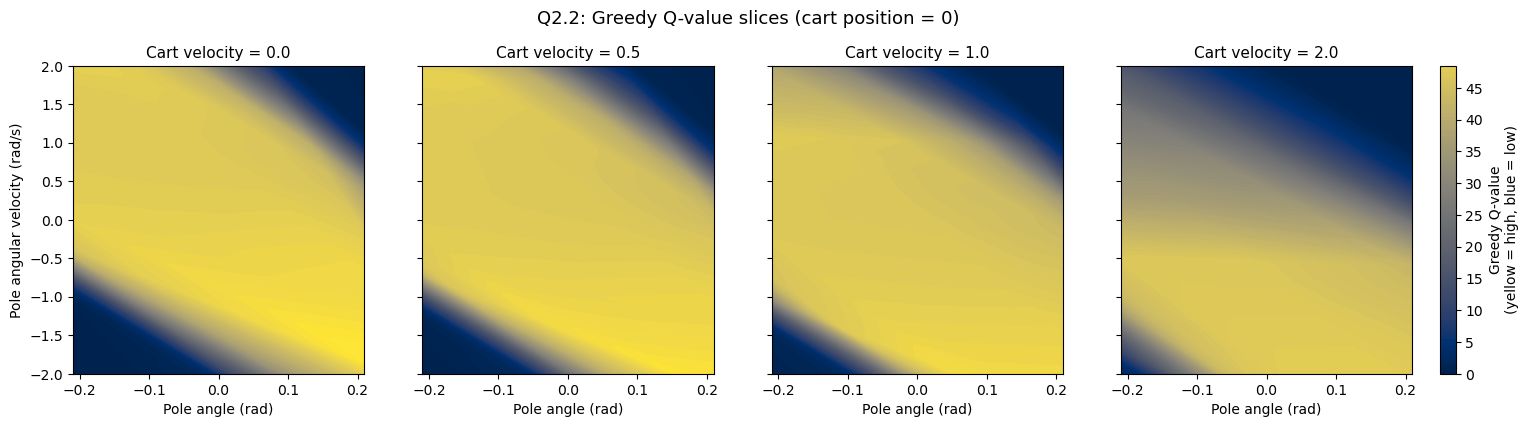

In [59]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

all_q_arrays = []

for cart_vel in cart_velocities:
    q_array = torch.zeros((n_samples, n_samples))
    for i, angle in enumerate(angles):
        for j, omega in enumerate(omegas):
            state = torch.tensor([0., cart_vel, angle, omega])
            with torch.no_grad():
                q_vals  = trained_policy_net(state)
                q_array[i, j] = q_vals.max().item()   
    all_q_arrays.append(q_array)

vmin = min(q.min().item() for q in all_q_arrays)
vmax = max(q.max().item() for q in all_q_arrays)

for ax, cart_vel, q_array in zip(axes, cart_velocities, all_q_arrays):
    img = ax.contourf(angles.numpy(), omegas.numpy(), q_array.T.numpy(),
                      levels=100, cmap='cividis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Cart velocity = {cart_vel}', fontsize=11)
    ax.set_xlabel('Pole angle (rad)', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('Pole angular velocity (rad/s)', fontsize=10)

cbar = fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Greedy Q-value\n(yellow = high, blue = low)', fontsize=10)

fig.suptitle('Q2.2: Greedy Q-value slices (cart position = 0)', fontsize=13, y=1.02)
#plt.tight_layout()
plt.savefig('qvalue_slices.png', dpi=150, bbox_inches='tight')
plt.show()